# sfig5 — Held-Out Context-Length Extrapolation (Supplementary Fig. S-5)

Fits a saturating power law AUROC(L) = c - a·L^(-b) using only the four
cheaper context lengths (30s, 10m, 40m, 80m), then checks whether it predicts
AUROC at the two more expensive held-out lengths (120m, 240m) — the direct
analog of the LLM scaling-law practice of fitting cheap/small runs to
forecast expensive/large ones, applied to context length instead of
model/compute size.

**Source**: analysis.csv (head=transformer, split=test, k=all)
**Tasks**: all 7 main + supplementary tasks
**Note**: see `markdown/SCALING_LAW_ANALYSIS_IDEAS.md` (Idea B) for the full
writeup and error table (`scaling_law_ideas/output/idea_b_extrapolation_errors.csv`).


In [2]:
%matplotlib inline

In [3]:
import sys
from pathlib import Path

# ── Workspace root: auto-detect by looking for final_results/ ─────────────────
def _find_workspace():
    """Walk up from CWD until we find a directory containing final_results/."""
    candidate = Path.cwd().resolve()
    for _ in range(10):
        if (candidate / "final_results").exists():
            return candidate
        if candidate.parent == candidate:
            break
        candidate = candidate.parent
    # Explicit fallback (edit this if auto-detect fails)
    return Path("/Users/boshra/NSRR-workspace").resolve()

WORKSPACE_ROOT = _find_workspace()
NSRR_TOOLS     = WORKSPACE_ROOT / "NSRR-tools"
FINAL_RESULTS  = WORKSPACE_ROOT / "final_results"
PAPER_FIGURES  = NSRR_TOOLS / "results" / "paper_figures"
FINAL_OUT      = PAPER_FIGURES / "final_npj"
FINAL_OUT.mkdir(parents=True, exist_ok=True)

# Add utils to path (notebooks/utils/)
_nb_dir = PAPER_FIGURES / "notebooks_npj"
sys.path.insert(0, str(_nb_dir))

from utils.style import (
    apply_tbme_style, save_figure, FULL_W, HALF_W,
    MAIN_TASKS, SUPP_TASKS, ALL_TASKS, BINARY_MAIN,
    HEAD_STYLE, TASK_LABEL, NUM_CLASSES, COHORT_COLOR,
    FONT_ANNOT, FONT_BASE, FONT_LABEL, FONT_TITLE,
)
from utils.data import set_root, load_analysis, load_heatmap, load_parquets, cohort_auroc_table
from utils import panels

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

set_root(WORKSPACE_ROOT)
apply_tbme_style()

# ── Confirm the workspace root is correct ─────────────────────────────────────
_ok = (WORKSPACE_ROOT / "final_results").exists()
print(f"WORKSPACE_ROOT : {WORKSPACE_ROOT}")
print(f"final_results/ : {'✓ found' if _ok else '✗ NOT FOUND — edit _find_workspace() fallback'}")


WORKSPACE_ROOT : /Users/boshra/NSRR-workspace
final_results/ : ✓ found


In [24]:
# Panel labeling helper
def add_panel_label(ax, label, x=0.02, y=0.97):
    ax.text(x, y, label, transform=ax.transAxes,
            fontsize=10, fontweight="bold", va="top", fontfamily="serif")


In [25]:
TASKS  = ALL_TASKS   # 7 tasks
HEAD   = "transformer"
SPLIT  = "test"
CHEAP_CONTEXTS = ("30s", "10m", "40m", "80m")
HELD_OUT_CONTEXTS = ("120m", "240m")
N_COLS = 3
N_ROWS = 3

df = load_analysis("phase0_v3", split=SPLIT, k="all")
print("Tasks:", TASKS)
print("analysis.csv rows (test, k=all):", df.shape)


Tasks: ['sex_binary', 'bmi_binary', 'age_class', 'sleep_efficiency_binary', 'apnea_binary', 'depression_extreme_binary', 'osa_binary_apples_postqc']
analysis.csv rows (test, k=all): (126, 26)


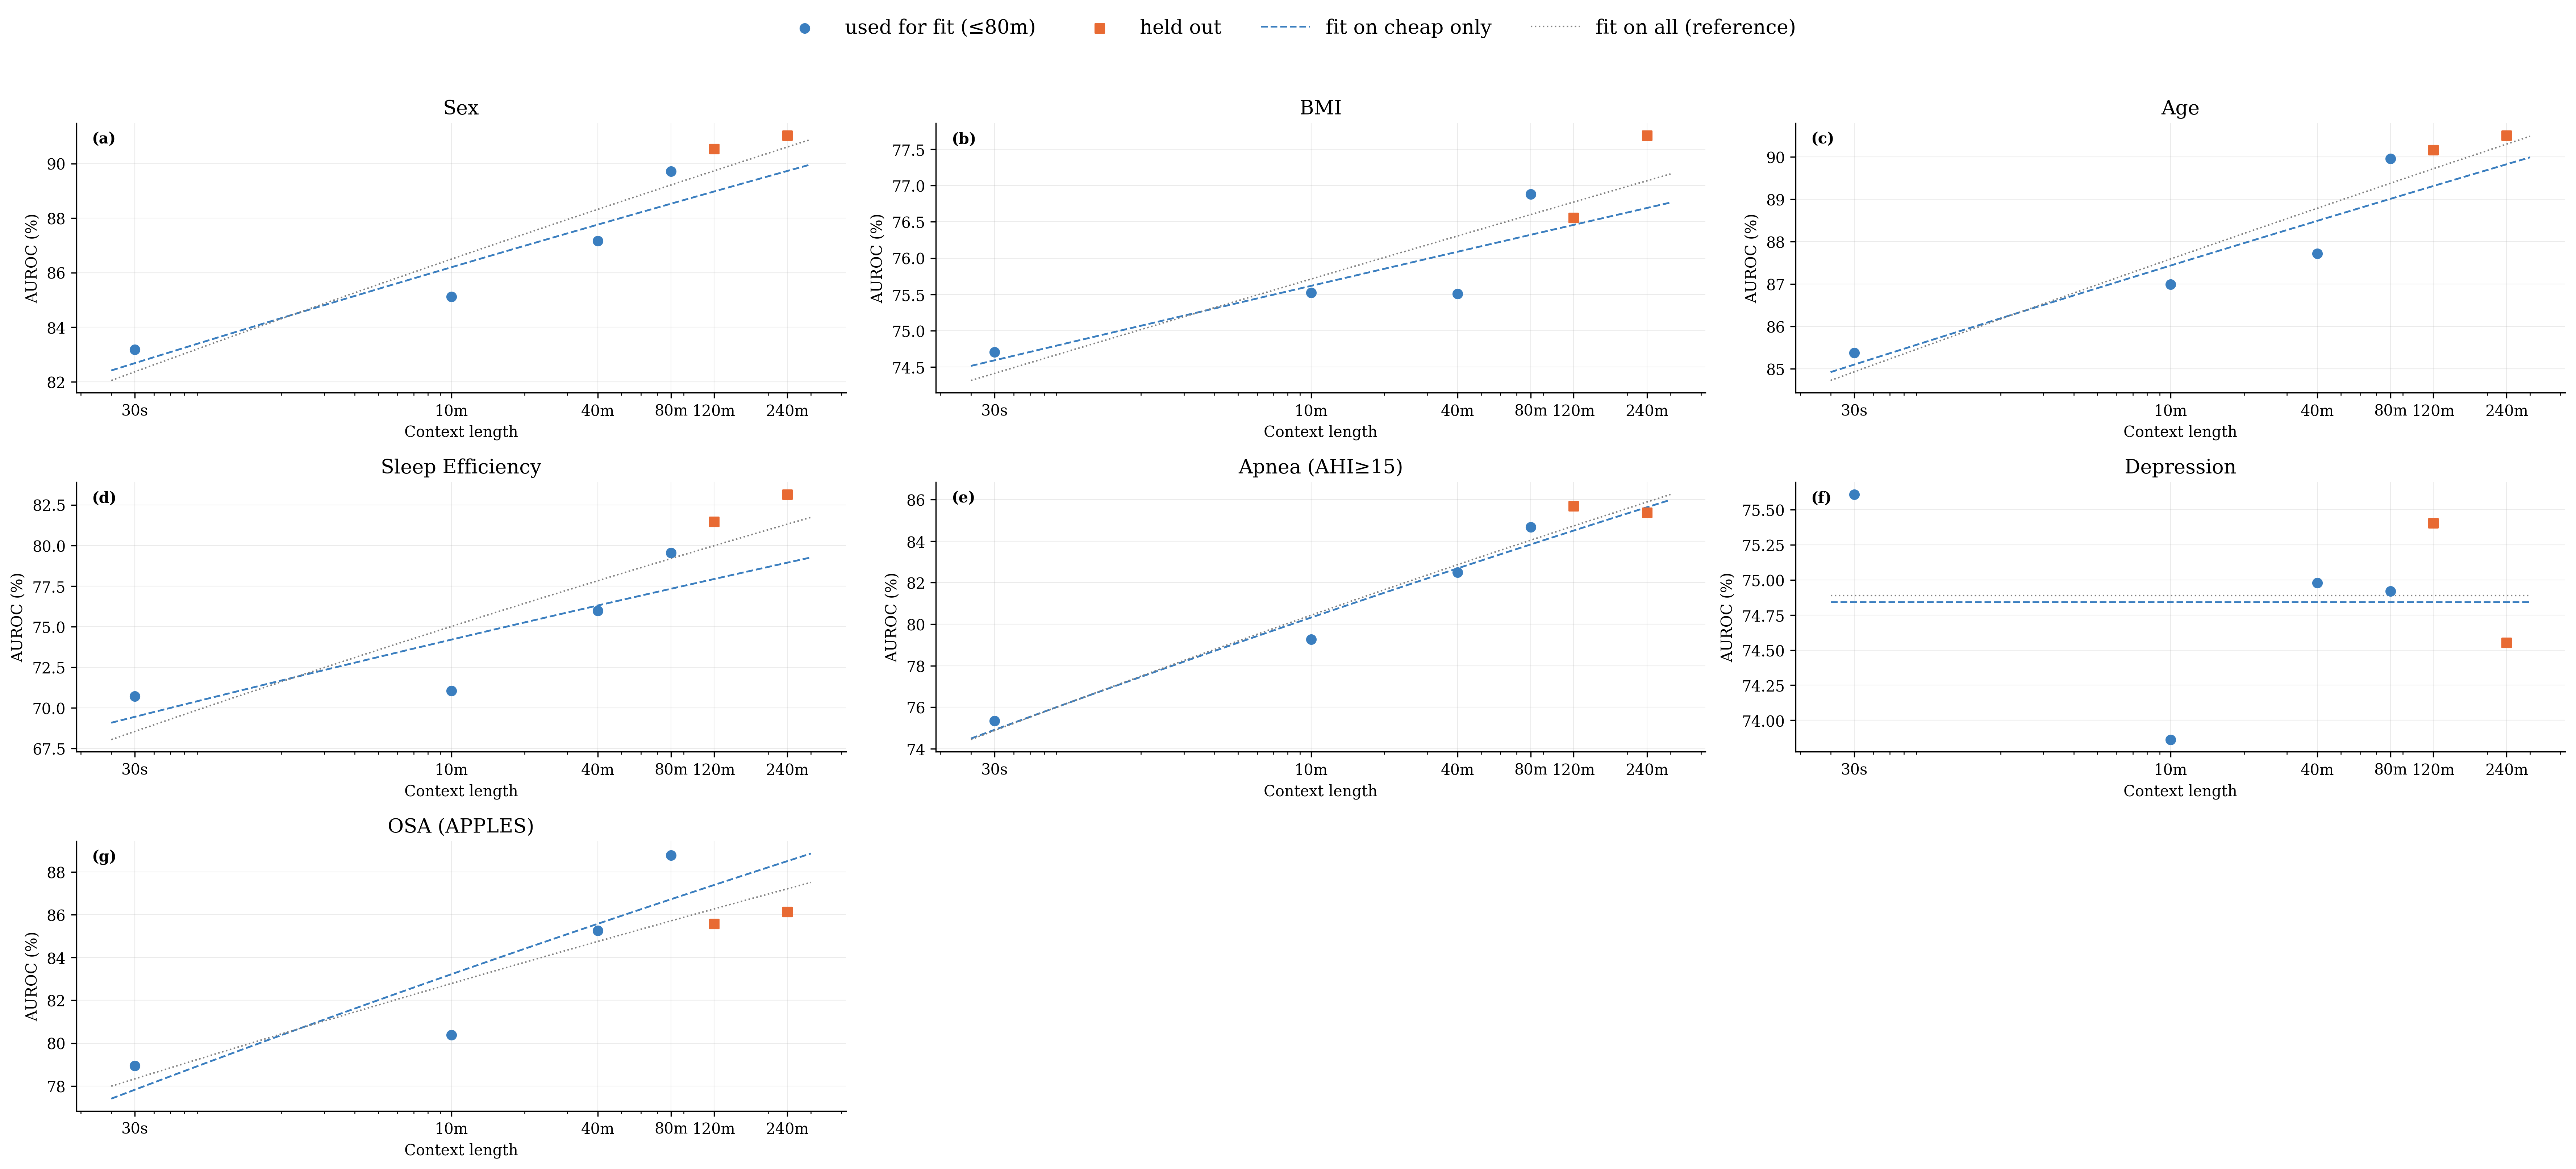


Extrapolation error (predicted - actual AUROC points), held-out contexts:
  sex_binary                   {'120m': -0.01559753620688098, '240m': -0.013069033637917449}
  bmi_binary                   {'120m': -0.000983446631911744, '240m': -0.00999898796882992}
  age_class                    {'120m': -0.008479144333672473, '240m': -0.006811983657875387}
  sleep_efficiency_binary      {'120m': -0.035298766779715884, '240m': -0.04201098287863525}
  apnea_binary                 {'120m': -0.011843158806809084, '240m': 0.002525000447018644}
  depression_extreme_binary    {'120m': -0.00564024356185544, '240m': 0.002896341805665781}
  osa_binary_apples_postqc     {'120m': 0.018097178512942125, '240m': 0.023694636807708336}


In [27]:
fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(FULL_W * 3.4, N_ROWS * 3.6))
axes_flat = axes.flatten()

extrapolation_errors = {}
for i, (ax, task) in enumerate(zip(axes_flat, TASKS)):
    errs = panels.context_extrapolation_panel(
        ax, df, task, head=HEAD,
        cheap_contexts=CHEAP_CONTEXTS, held_out_contexts=HELD_OUT_CONTEXTS,
        legend=False,
    )
    extrapolation_errors[task] = errs
    ax.set_title(TASK_LABEL.get(task, task), fontsize=FONT_TITLE+3)
    add_panel_label(ax, f"({chr(97+i)})")

for ax in axes_flat[len(TASKS):]:
    ax.set_visible(False)

# Single shared legend at the top
_h, _l = axes_flat[0].get_legend_handles_labels()
fig.legend(_h, _l, loc="upper center", ncol=len(_h),
           fontsize=FONT_ANNOT+3, frameon=False,
           bbox_to_anchor=(0.5, 1.00), handlelength=2.5)

fig.tight_layout(h_pad=1.2, w_pad=1.0, rect=[0, 0, 1, 0.93])
plt.show()

print("\nExtrapolation error (predicted - actual AUROC points), held-out contexts:")
for task, errs in extrapolation_errors.items():
    print(f"  {task:28s} {errs}")


In [ ]:
# ── Run when figure looks good ──────────────────────────────
save_figure(fig, FINAL_OUT, "sfig5_context_extrapolation")
import shutil
shutil.copy(FINAL_OUT / "sfig5_context_extrapolation.pdf",
            WORKSPACE_ROOT / "npj_digital_medicine_submission" / "sfig5_context_extrapolation.pdf")
print("Saved + copied → npj_digital_medicine_submission/sfig5_context_extrapolation.pdf")


  saved → /Users/boshra/NSRR-workspace/NSRR-tools/results/paper_figures/final_npj/sfig3_context_extrapolation.pdf
Saved + copied → npj_digital_medicine_submission/sfig3_context_extrapolation.pdf
